In [13]:
import yfinance as yf

In [11]:
pip install yfinance

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [15]:
sp500 = yf.Ticker("^GSPC")

In [21]:
sp500 = sp500.history(period = "max")

In [12]:
sp500

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
1927-12-30 00:00:00-05:00,17.660000,17.660000,17.660000,17.660000,0,0.0,0.0
1928-01-03 00:00:00-05:00,17.760000,17.760000,17.760000,17.760000,0,0.0,0.0
1928-01-04 00:00:00-05:00,17.719999,17.719999,17.719999,17.719999,0,0.0,0.0
1928-01-05 00:00:00-05:00,17.549999,17.549999,17.549999,17.549999,0,0.0,0.0
1928-01-06 00:00:00-05:00,17.660000,17.660000,17.660000,17.660000,0,0.0,0.0
...,...,...,...,...,...,...,...
2026-02-24 00:00:00-05:00,6837.370117,6899.169922,6815.430176,6890.069824,5266090000,0.0,0.0
2026-02-25 00:00:00-05:00,6915.149902,6952.509766,6915.149902,6946.129883,5328060000,0.0,0.0
2026-02-26 00:00:00-05:00,6944.740234,6947.250000,6859.729980,6908.859863,5889550000,0.0,0.0


In [23]:
sp500.index

DatetimeIndex(['1927-12-30 00:00:00-05:00', '1928-01-03 00:00:00-05:00',
               '1928-01-04 00:00:00-05:00', '1928-01-05 00:00:00-05:00',
               '1928-01-06 00:00:00-05:00', '1928-01-09 00:00:00-05:00',
               '1928-01-10 00:00:00-05:00', '1928-01-11 00:00:00-05:00',
               '1928-01-12 00:00:00-05:00', '1928-01-13 00:00:00-05:00',
               ...
               '2026-02-17 00:00:00-05:00', '2026-02-18 00:00:00-05:00',
               '2026-02-19 00:00:00-05:00', '2026-02-20 00:00:00-05:00',
               '2026-02-23 00:00:00-05:00', '2026-02-24 00:00:00-05:00',
               '2026-02-25 00:00:00-05:00', '2026-02-26 00:00:00-05:00',
               '2026-02-27 00:00:00-05:00', '2026-03-02 00:00:00-05:00'],
              dtype='datetime64[ns, America/New_York]', name='Date', length=24657, freq=None)

<Axes: xlabel='Date'>

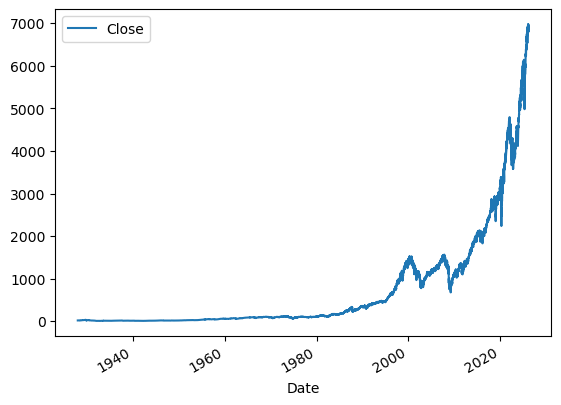

In [25]:
sp500.plot.line(y= "Close" ,use_index = True)

In [27]:
del sp500["Dividends"]
del sp500["Stock Splits"]

In [20]:
sp500

,Open,High,Low,Close,Volume
Date,,,,,
1927-12-30 00:00:00-05:00,17.660000,17.660000,17.660000,17.660000,0
1928-01-03 00:00:00-05:00,17.760000,17.760000,17.760000,17.760000,0
1928-01-04 00:00:00-05:00,17.719999,17.719999,17.719999,17.719999,0
1928-01-05 00:00:00-05:00,17.549999,17.549999,17.549999,17.549999,0
1928-01-06 00:00:00-05:00,17.660000,17.660000,17.660000,17.660000,0
...,...,...,...,...,...
2026-02-24 00:00:00-05:00,6837.370117,6899.169922,6815.430176,6890.069824,5266090000
2026-02-25 00:00:00-05:00,6915.149902,6952.509766,6915.149902,6946.129883,5328060000
2026-02-26 00:00:00-05:00,6944.740234,6947.250000,6859.729980,6908.859863,5889550000


In [29]:
sp500["Tomorrow"] = sp500["Close"].shift(-1)

In [24]:
sp500


,Open,High,Low,Close,Volume,Tomorrow
Date,,,,,,
1927-12-30 00:00:00-05:00,17.660000,17.660000,17.660000,17.660000,0,17.760000
1928-01-03 00:00:00-05:00,17.760000,17.760000,17.760000,17.760000,0,17.719999
1928-01-04 00:00:00-05:00,17.719999,17.719999,17.719999,17.719999,0,17.549999
1928-01-05 00:00:00-05:00,17.549999,17.549999,17.549999,17.549999,0,17.660000
1928-01-06 00:00:00-05:00,17.660000,17.660000,17.660000,17.660000,0,17.500000
...,...,...,...,...,...,...
2026-02-24 00:00:00-05:00,6837.370117,6899.169922,6815.430176,6890.069824,5266090000,6946.129883
2026-02-25 00:00:00-05:00,6915.149902,6952.509766,6915.149902,6946.129883,5328060000,6908.859863
2026-02-26 00:00:00-05:00,6944.740234,6947.250000,6859.729980,6908.859863,5889550000,6878.879883


In [36]:
sp500["Target"] = (sp500["Tomorrow"] >sp500["Close"]).astype(int)

In [28]:
sp500


,Open,High,Low,Close,Volume,Tomorrow,Target
Date,,,,,,,
1927-12-30 00:00:00-05:00,17.660000,17.660000,17.660000,17.660000,0,17.760000,1
1928-01-03 00:00:00-05:00,17.760000,17.760000,17.760000,17.760000,0,17.719999,0
1928-01-04 00:00:00-05:00,17.719999,17.719999,17.719999,17.719999,0,17.549999,0
1928-01-05 00:00:00-05:00,17.549999,17.549999,17.549999,17.549999,0,17.660000,1
1928-01-06 00:00:00-05:00,17.660000,17.660000,17.660000,17.660000,0,17.500000,0
...,...,...,...,...,...,...,...
2026-02-24 00:00:00-05:00,6837.370117,6899.169922,6815.430176,6890.069824,5266090000,6946.129883,1
2026-02-25 00:00:00-05:00,6915.149902,6952.509766,6915.149902,6946.129883,5328060000,6908.859863,0
2026-02-26 00:00:00-05:00,6944.740234,6947.250000,6859.729980,6908.859863,5889550000,6878.879883,0


In [38]:
sp500 = sp500.loc["1990-01-01":].copy()

In [40]:
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(n_estimators = 1000 ,min_samples_split = 100, random_state = 1)
train = sp500.iloc[:-100]
test = sp500.iloc[-100:]
predictors = ["Close","Volume","Open","High","Low"]
model.fit(train[predictors],train["Target"])

RandomForestClassifier(min_samples_split=100, n_estimators=1000, random_state=1)

In [41]:
from sklearn.metrics import precision_score
preds = model.predict(test[predictors])

In [42]:
import pandas as pd
preds = pd.Series(preds,index = test.index)

In [43]:
preds


Date
2025-10-07 00:00:00-04:00    1
2025-10-08 00:00:00-04:00    1
2025-10-09 00:00:00-04:00    1
2025-10-10 00:00:00-04:00    1
2025-10-13 00:00:00-04:00    1
                            ..
2026-02-24 00:00:00-05:00    1
2026-02-25 00:00:00-05:00    1
2026-02-26 00:00:00-05:00    1
2026-02-27 00:00:00-05:00    1
2026-03-02 00:00:00-05:00    1
Length: 100, dtype: int32

In [44]:
precision_score(test["Target"],preds)

0.5789473684210527

In [52]:
combined = pd.concat([test["Target"],preds],axis = 1)


<Axes: xlabel='Date'>

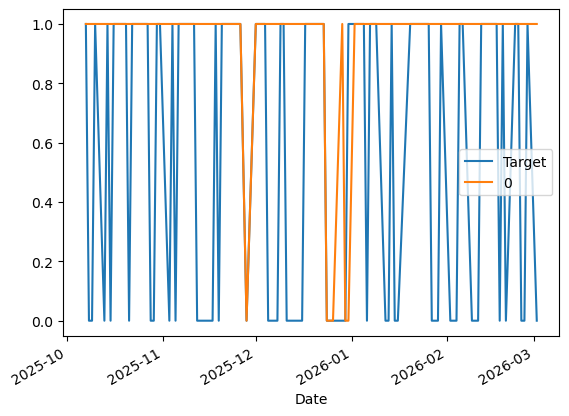

In [54]:
combined.plot()

In [56]:
def predict(train ,test,predictors,model):
    model.fit(train[predictors] ,train["Target"])
    preds = model.predict(test[predictors])
    preds = pd.Series(preds, index = test.index , name = "Predictions")
    combined = pd.concat([test["Target"],preds], axis = 1)
    return combined

In [58]:
def backtest(data,model,predictors,start = 2500, step = 250):
    all_predictions = []
    for i in range(start, data.shape[0],step ):
        train = data.iloc[0:i].copy()
        test = data.iloc[i:(i+step)].copy()
        predictions = predict(train,test,predictors,model)
        all_predictions.append(predictions)
    return pd.concat(all_predictions)

In [60]:
predictions = backtest(sp500,model,predictors)

In [66]:
predictions["Predictions"].value_counts()

Predictions
0    3919
1    2688
Name: count, dtype: int64

In [68]:
precision_score(predictions["Target"],predictions["Predictions"])

0.5334821428571429

In [70]:
predictions["Target"].value_counts()/predictions.shape[0]




Target
1    0.53746
0    0.46254
Name: count, dtype: float64

In [80]:
horizons = [2,5,60,250,1000]
new_predictors = []
for horizon in horizons:
    rolling_averages = sp500.rolling(horizon).mean()
    ratio_column = f"Close_Ratio_{horizon}"
    sp500[ratio_column] = sp500["Close"]/rolling_averages["Close"]
    trend_column = f"Trend_{horizon}"
    sp500[trend_column] = sp500.shift(1).rolling(horizon).sum()["Target"]
    new_predictors += [ratio_column, trend_column] 
    


In [82]:
sp500


,Open,High,Low,Close,Volume,Tomorrow,Target,Close_Ratio_2,Trend_2,Close_Ratio_5,Trend_5,Close_Ratio_60,Trend_60,Close_Ratio_250,Trend_250,Close_Ratio_1000,Trend_1000
Date,,,,,,,,,,,,,,,,,
1990-01-02 00:00:00-05:00,353.399994,359.690002,351.980011,359.690002,162070000,358.760010,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1990-01-03 00:00:00-05:00,359.690002,360.589996,357.890015,358.760010,192330000,355.670013,0,0.998706,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1990-01-04 00:00:00-05:00,358.760010,358.760010,352.890015,355.670013,177000000,352.200012,0,0.995675,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1990-01-05 00:00:00-05:00,355.670013,355.670013,351.350006,352.200012,158530000,353.790009,1,0.995098,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1990-01-08 00:00:00-05:00,352.200012,354.239990,350.540009,353.790009,140110000,349.619995,0,1.002252,1.0,0.993731,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-02-24 00:00:00-05:00,6837.370117,6899.169922,6815.430176,6890.069824,5266090000,6946.129883,1,1.003811,1.0,1.002031,3.0,1.000351,33.0,1.085738,144.0,1.352356,536.0
2026-02-25 00:00:00-05:00,6915.149902,6952.509766,6915.149902,6946.129883,5328060000,6908.859863,0,1.004052,2.0,1.008283,3.0,1.008164,33.0,1.093890,144.0,1.362654,537.0
2026-02-26 00:00:00-05:00,6944.740234,6947.250000,6859.729980,6908.859863,5889550000,6878.879883,0,0.997310,1.0,1.001507,3.0,1.002610,32.0,1.087303,144.0,1.354672,536.0


In [84]:
sp500 = sp500.dropna()

In [86]:
sp500

,Open,High,Low,Close,Volume,Tomorrow,Target,Close_Ratio_2,Trend_2,Close_Ratio_5,Trend_5,Close_Ratio_60,Trend_60,Close_Ratio_250,Trend_250,Close_Ratio_1000,Trend_1000
Date,,,,,,,,,,,,,,,,,
1993-12-14 00:00:00-05:00,465.730011,466.119995,462.459991,463.059998,275050000,461.839996,0,0.997157,1.0,0.996617,1.0,1.000283,32.0,1.028047,127.0,1.176082,512.0
1993-12-15 00:00:00-05:00,463.059998,463.690002,461.839996,461.839996,331770000,463.339996,1,0.998681,0.0,0.995899,1.0,0.997329,32.0,1.025151,126.0,1.172676,512.0
1993-12-16 00:00:00-05:00,461.859985,463.980011,461.859985,463.339996,284620000,466.380005,1,1.001621,1.0,0.999495,2.0,1.000311,32.0,1.028274,127.0,1.176163,513.0
1993-12-17 00:00:00-05:00,463.339996,466.380005,463.339996,466.380005,363750000,465.850006,0,1.003270,2.0,1.004991,3.0,1.006561,32.0,1.034781,128.0,1.183537,514.0
1993-12-20 00:00:00-05:00,466.380005,466.899994,465.529999,465.850006,255900000,465.299988,0,0.999431,1.0,1.003784,2.0,1.005120,32.0,1.033359,128.0,1.181856,513.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-02-23 00:00:00-05:00,6901.250000,6916.959961,6819.819824,6837.750000,5638350000,6890.069824,1,0.994780,1.0,0.995779,3.0,0.993053,33.0,1.078129,143.0,1.342750,535.0
2026-02-24 00:00:00-05:00,6837.370117,6899.169922,6815.430176,6890.069824,5266090000,6946.129883,1,1.003811,1.0,1.002031,3.0,1.000351,33.0,1.085738,144.0,1.352356,536.0
2026-02-25 00:00:00-05:00,6915.149902,6952.509766,6915.149902,6946.129883,5328060000,6908.859863,0,1.004052,2.0,1.008283,3.0,1.008164,33.0,1.093890,144.0,1.362654,537.0


In [114]:
model = RandomForestClassifier(n_estimators = 500 , min_samples_split = 50, random_state = 1)

In [116]:
def predict(train ,test,predictors,model):
    model.fit(train[predictors] ,train["Target"])
    preds = model.predict_proba(test[predictors])[:,1]
    preds[preds >= .6] = 1
    preds[preds <.6] = 0
    preds = pd.Series(preds, index = test.index , name = "Predictions")
    combined = pd.concat([test["Target"],preds], axis = 1)
    return combined

In [118]:
predictions["Predictions"].value_counts()

Predictions
0.0    4733
1.0     873
Name: count, dtype: int64

In [120]:
precision_score(predictions["Target"],predictions["Predictions"])

0.5761741122565864

In [110]:
combined = pd.concat([test["Target"],predictions["Predictions"]],axis = 1)


<Axes: xlabel='Date'>

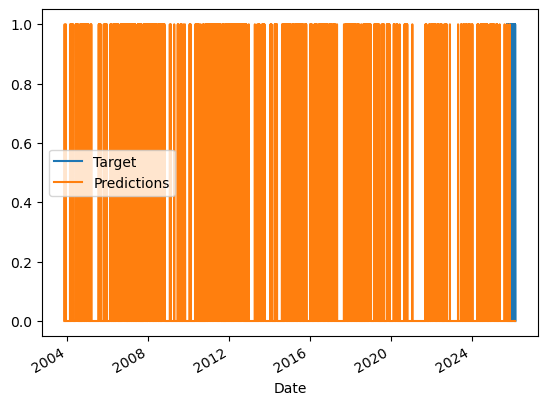

In [112]:
combined.plot()

In [122]:
precision_score(predictions["Target"],predictions["Predictions"])

0.5761741122565864